### Import Libraries

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

### Load Dataset

In [37]:
df = pd.read_csv("Battery_dataset.csv")
df.head()

,battery_id,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
0,B5,1,1.440147,4.254682,23.988733,1.894407,3.273523,32.980834,1.986196,99.309790,219
1,B5,2,1.416595,4.159825,25.665347,1.829949,4.038741,32.257920,1.986240,99.311985,218
2,B5,3,1.420272,4.276323,25.407910,1.942105,3.214433,35.134801,1.984252,99.212608,217
3,B5,4,1.337680,4.236697,27.069757,2.073577,3.134529,32.082988,1.969236,98.461812,216
4,B5,5,1.263946,4.142791,26.478353,2.049885,3.729341,32.483154,1.974862,98.743106,215


### Understand Data

In [38]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   battery_id  680 non-null    object 
 1   cycle       680 non-null    int64  
 2   chI         680 non-null    float64
 3   chV         680 non-null    float64
 4   chT         680 non-null    float64
 5   disI        680 non-null    float64
 6   disV        680 non-null    float64
 7   disT        680 non-null    float64
 8   BCt         680 non-null    float64
 9   SOH         680 non-null    float64
 10  RUL         680 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 58.6+ KB


,cycle,chI,chV,chT,disI,disV,disT,BCt,SOH,RUL
count,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000,680.000000
mean,114.470588,1.400069,4.202765,26.871113,2.007630,3.501070,33.099894,1.427851,71.392565,113.470588
std,66.601594,0.102903,0.046973,1.489824,0.097797,0.304160,1.827415,0.333250,16.662488,66.601594
min,1.000000,1.000859,4.035078,21.604784,1.702438,2.484857,26.848457,0.750972,37.548593,0.000000
25%,57.000000,1.333381,4.170685,25.822944,1.945474,3.299257,31.910717,1.146314,57.315723,56.000000
50%,114.000000,1.401904,4.202503,26.823350,2.006990,3.496967,33.105426,1.429413,71.470656,113.000000
75%,170.250000,1.469383,4.235014,27.944619,2.066924,3.718415,34.328265,1.713894,85.694686,169.250000
max,250.000000,1.747515,4.359233,30.913077,2.411226,4.363548,38.388721,1.993692,99.684587,249.000000


### Check Missing Values

In [39]:
df.isnull().sum()

battery_id    0
cycle         0
chI           0
chV           0
chT           0
disI          0
disV          0
disT          0
BCt           0
SOH           0
RUL           0
dtype: int64

### Basic Visualization

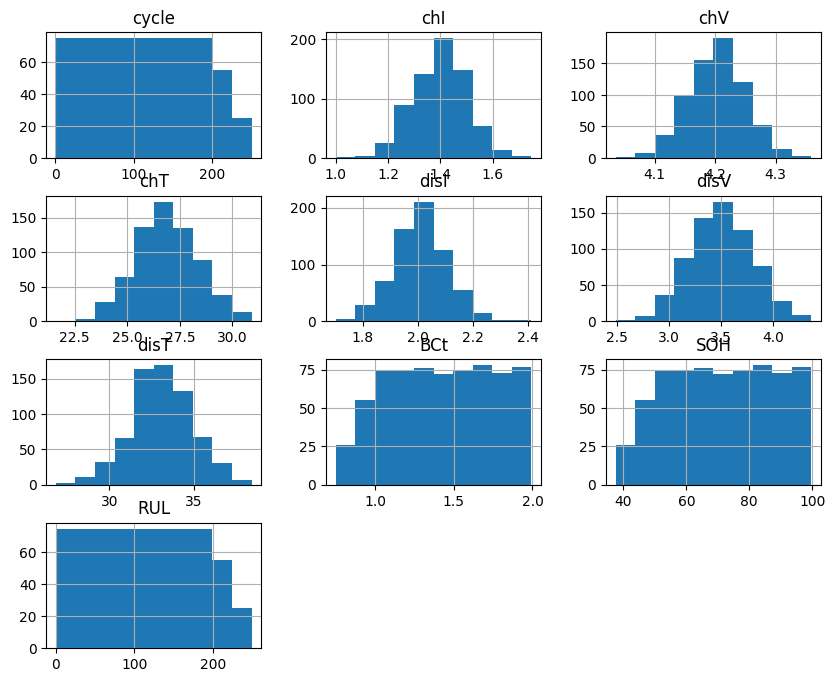

In [40]:
df.hist(figsize=(10,8))
plt.show()

### Create REAL Target

In [41]:
y = df["RUL"]   # Remaining Useful Life (BEST target)

### Select Features

In [42]:
print(df.columns)

Index(['battery_id', 'cycle', 'chI', 'chV', 'chT', 'disI', 'disV', 'disT',
       'BCt', 'SOH', 'RUL'],
      dtype='object')


In [43]:
X = df[
    [
        "cycle",
        "chI", "chV", "chT",
        "disI", "disV", "disT"
    ]
]

### Train-Test Split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train Linear Regression

In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression R2:", r2_score(y_test, lr_pred))

Linear Regression R2: 0.9307698883993882


### Train XGBoost

In [46]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost R2:", r2_score(y_test, xgb_pred))

XGBoost R2: 0.8745434284210205
